# Create tracer surface fluxes

In [1]:
import xarray as xr

In [2]:
ds_grid = xr.open_dataset("../../INPUT/pacmed12_grd.nc")

## Release locations

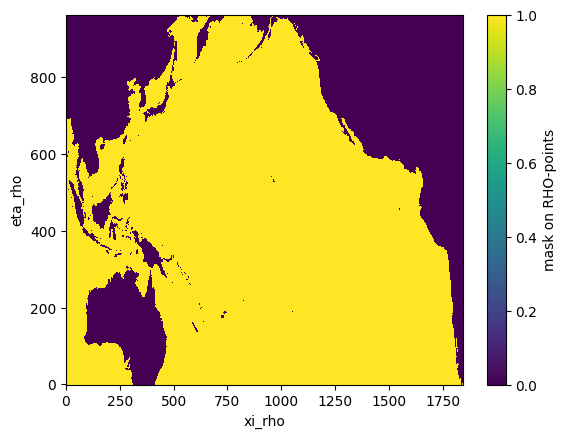

In [3]:
ds_grid["mask_rho"].plot()

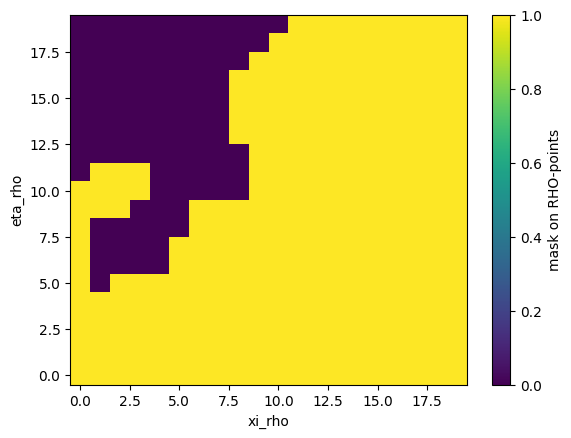

In [4]:
ds_grid["mask_rho"].isel(eta_rho=slice(700, 720), xi_rho=slice(450, 470)).plot()

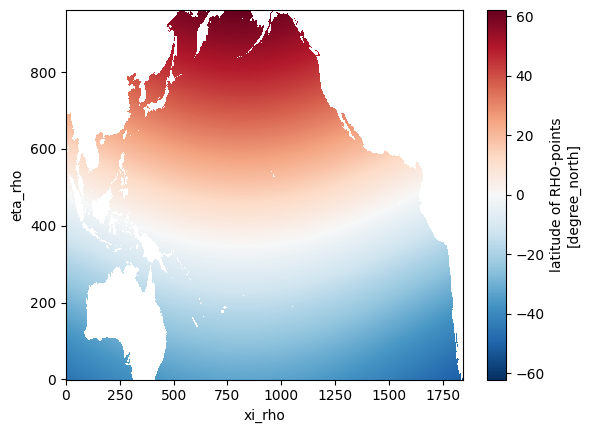

In [5]:
ds_grid["lat_rho"].where(ds_grid.mask_rho).plot()

In [6]:
import gcm_filters

In [7]:
# Calculate the grid cell area from the inverse grid metrics (pm, pn)
area = 1 / (ds_grid.pm * ds_grid.pn)

# Compute the mean grid spacing (dx) as the average of mean dx and dy
dx = (((1 / ds_grid.pm).mean() + (1 / ds_grid.pn).mean()) / 2).item()

# Extend the domain in both dimensions to mitigate boundary effects during filtering
# - Create a mask of ones ignoring land (will be renormalized later)
mask = xr.ones_like(ds_grid.mask_rho)

In [8]:
std = 300000 # 300 km

In [9]:
import numpy as np

In [10]:
# Define Gaussian filter parameters:
# - filter_scale is computed so that the Gaussian's std dev matches
#   the equivalent boxcar filter of width equal to release.hsc / dx
#   multiplied by sqrt(12) to convert from boxcar to Gaussian std dev.
filter_scale = std / dx * np.sqrt(12)

filter = gcm_filters.Filter(
    filter_scale=filter_scale,
    dx_min=1,
    filter_shape=gcm_filters.FilterShape.GAUSSIAN,
    grid_type=gcm_filters.GridType.REGULAR_WITH_LAND_AREA_WEIGHTED,
    grid_vars={"wet_mask": mask, "area": area},
)

In [11]:
def create_gaussian(delta):
    delta_smooth = filter.apply(delta, dims=["eta_rho", "xi_rho"])
    
    # Mask out land cells and set values to zero there
    delta_smooth = delta_smooth.where(ds_grid.mask_rho, 0.0)

    integral = (delta_smooth * area).sum(dim=["eta_rho", "xi_rho"]) / area.sum(dim=["eta_rho", "xi_rho"])
    delta_smooth = delta_smooth / integral 

    return delta_smooth

In [12]:
releases = {}

### Vancouver Island: 50 degrees North (subpolar latitudes)

In [13]:
eta_rho = 855
xi_rho = 1135

In [14]:
delta = xr.zeros_like(ds_grid["mask_rho"])
delta[eta_rho, xi_rho] = 1 / area[eta_rho, xi_rho]

In [15]:
ds_grid.lat_rho[eta_rho, xi_rho].values

array(50.02569606)

In [16]:
release_vancouver_island = create_gaussian(delta)

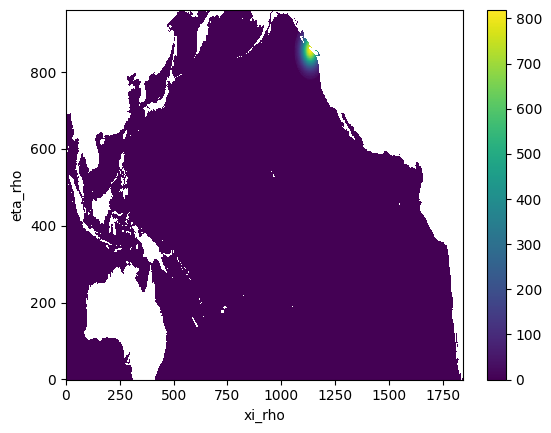

In [17]:
release_vancouver_island.where(ds_grid.mask_rho).plot()

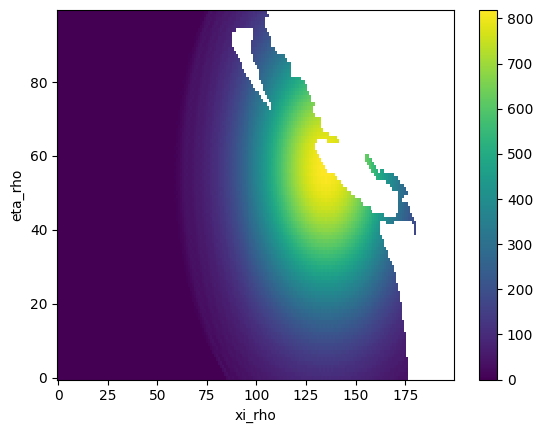

In [18]:
release_vancouver_island.where(ds_grid.mask_rho).isel(xi_rho=slice(1000, 1200), eta_rho=slice(800, 900)).plot()

In [19]:
releases["VI"] = release_vancouver_island

### Salish Sea: 48.5 degrees North (subpolar latitudes)

In [20]:
eta_rho = 842
xi_rho = 1160

In [21]:
delta = xr.zeros_like(ds_grid["mask_rho"])
delta[eta_rho, xi_rho] = 1 / area[eta_rho, xi_rho]

In [22]:
ds_grid.lat_rho[eta_rho, xi_rho].values

array(48.39198663)

In [23]:
release_salish_sea = create_gaussian(delta)

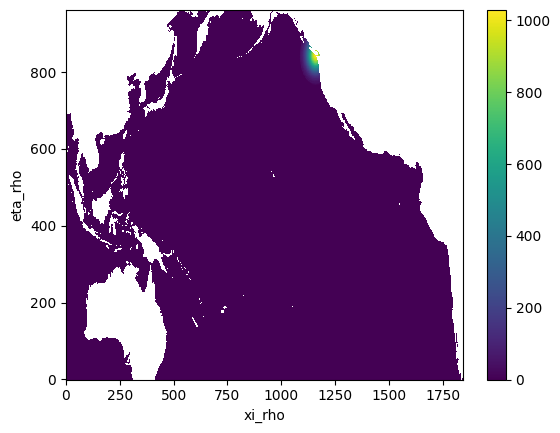

In [24]:
release_salish_sea.where(ds_grid.mask_rho).plot()

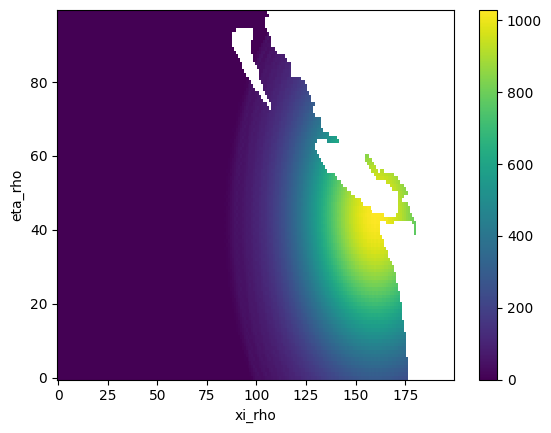

In [25]:
release_salish_sea.where(ds_grid.mask_rho).isel(xi_rho=slice(1000, 1200), eta_rho=slice(800, 900)).plot()

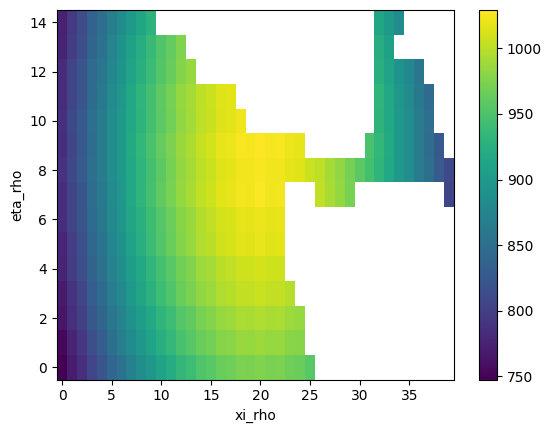

In [26]:
release_salish_sea.where(ds_grid.mask_rho).isel(xi_rho=slice(1140, 1180), eta_rho=slice(835, 850)).plot()

In [27]:
releases["SS"] = release_salish_sea

### Baja California: 27 degrees North (subtropical latitudes)

In [28]:
eta_rho = 650
xi_rho = 1290

In [29]:
delta = xr.zeros_like(ds_grid["mask_rho"])
delta[eta_rho, xi_rho] = 1 / area[eta_rho, xi_rho]

In [30]:
ds_grid.lat_rho[eta_rho, xi_rho].values

array(27.05098527)

In [31]:
release_baja_california = create_gaussian(delta)

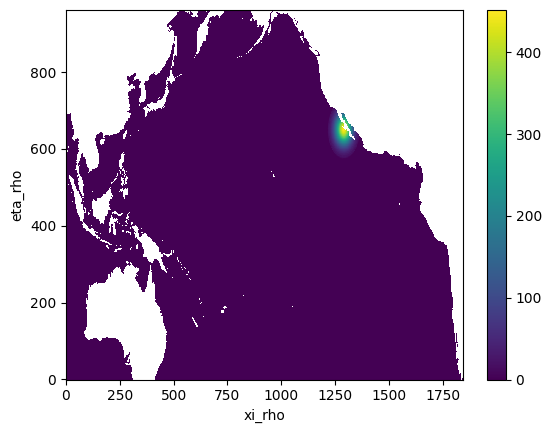

In [32]:
release_baja_california.where(ds_grid.mask_rho).plot()

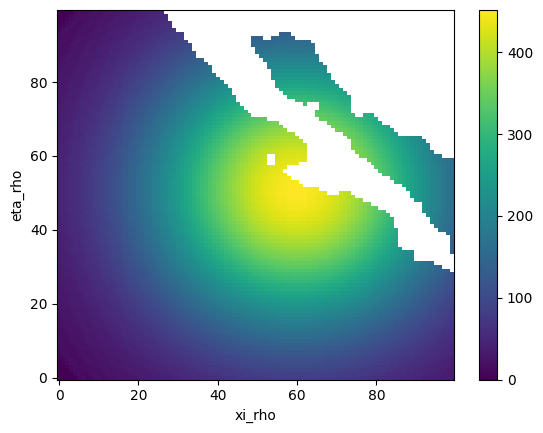

In [33]:
release_baja_california.where(ds_grid.mask_rho).isel(xi_rho=slice(1230, 1330), eta_rho=slice(600, 700)).plot()

In [34]:
releases["BC"] = release_baja_california

### Ecuador: 0.5 degrees North (equatorial latitudes)

In [35]:
eta_rho = 490
xi_rho = 1640

In [36]:
delta = xr.zeros_like(ds_grid["mask_rho"])
delta[eta_rho, xi_rho] = 1 / area[eta_rho, xi_rho]

In [37]:
ds_grid.lat_rho[eta_rho, xi_rho].values

array(0.42402018)

In [38]:
release_ecuador = create_gaussian(delta)

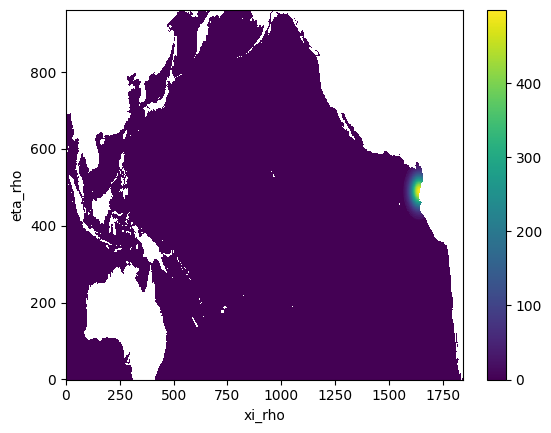

In [39]:
release_ecuador.where(ds_grid.mask_rho).plot()

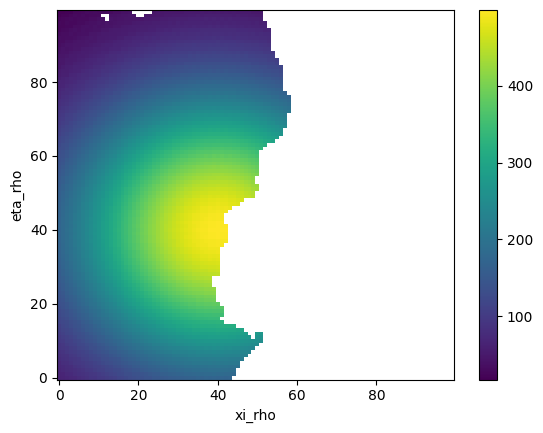

In [40]:
release_ecuador.where(ds_grid.mask_rho).isel(xi_rho=slice(1600, 1700), eta_rho=slice(450, 550)).plot()

In [41]:
releases["EC"] = release_ecuador

### Japan

In [42]:
xi_rho = 459
eta_rho = 710

In [43]:
delta = xr.zeros_like(ds_grid["mask_rho"])
delta[eta_rho, xi_rho] = 1 / area[eta_rho, xi_rho]

In [44]:
ds_grid.lat_rho[eta_rho, xi_rho].values

array(35.70591541)

In [45]:
ds_grid.lon_rho[eta_rho, xi_rho].values

array(-219.19518739)

In [46]:
release_japan = create_gaussian(delta)

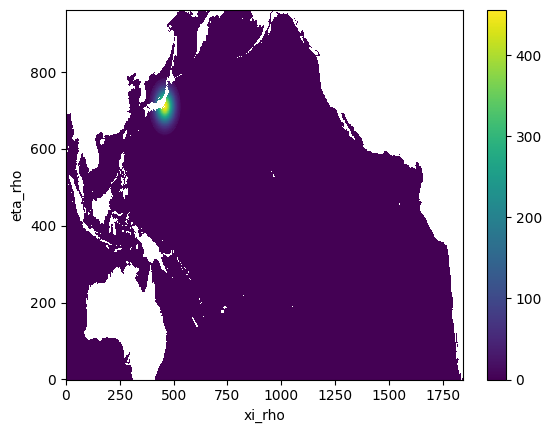

In [47]:
release_japan.where(ds_grid.mask_rho).plot()

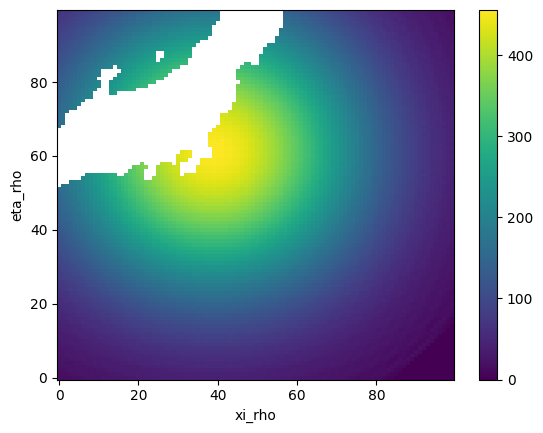

In [48]:
release_japan.where(ds_grid.mask_rho).isel(xi_rho=slice(420, 520), eta_rho=slice(650, 750)).plot()

In [49]:
releases["JP"] = release_japan

## Time coordinate
We need everything wrt reference date January 1, 1995.

In [50]:
ds_sfc_199912 = xr.open_dataset("/path/to/scratch/pacific/INPUT/frc_joined/pacmed12_frc.199912.nc", decode_timedelta=False)
ds_sfc_200001 = xr.open_dataset("/path/to/scratch/pacific/INPUT/frc_joined/pacmed12_frc.200001.nc", decode_timedelta=False)
ds_sfc_200002 = xr.open_dataset("/path/to/scratch/pacific/INPUT/frc_joined/pacmed12_frc.200002.nc", decode_timedelta=False)
ds_sfc_202101 = xr.open_dataset("/path/to/scratch/pacific/INPUT/frc_joined/pacmed12_frc.202101.nc", decode_timedelta=False)

In [51]:
time_1999 = ds_sfc_199912.time[-20:]
time0 = ds_sfc_200001.time
time1 = ds_sfc_200002.time[:20]
time_2000 = xr.concat([time0, time1], dim="time")
time_2021 = ds_sfc_202101.time[-1:]

In [52]:
ds_1999 = xr.Dataset()
ds_2000 = xr.Dataset()
ds_2021 = xr.Dataset()

In [53]:
ds_1999["time"] = time_1999
ds_2000["time"] = time_2000
ds_2021["time"] = time_2021

In [54]:
norm = 1/5.791/10**20

In [55]:
amplitudes = {"7": 10**14*norm, "8": 10**15*norm, "9": 10**16*norm, "10": 10**13*norm, "11": 10**12*norm}

In [56]:
for tracer_name, release in releases.items():
    for ampl, factor in amplitudes.items():
        ds_1999[f"{tracer_name}{ampl}"] = xr.zeros_like(ds_1999.time * release)
        ds_2000[f"{tracer_name}{ampl}"] = factor * xr.concat(
            [
                xr.ones_like(time0) * release,
                xr.zeros_like(time1 * release)
            ],
            dim="time"
        )
        ds_2021[f"{tracer_name}{ampl}"] = xr.zeros_like(ds_2021.time * release)

    for ds in [ds_1999, ds_2000, ds_2021]:
        ds[f"{tracer_name}{ampl}"].attrs = {
            "long_name": "tracer flux into ocean",
            "units": "1/m2/s"
        }

In [57]:
import matplotlib.pyplot as plt

In [59]:
def plot_tracer(ds, time=0):
    fig, axs = plt.subplots(5, 5, figsize=(25, 25))
    for i, tracer_name in enumerate(releases.keys()):
        for j, ampl in enumerate(amplitudes.keys()):
            field = ds[f"{tracer_name}{ampl}"].isel(time=time).where(ds_grid.mask_rho)
            field.plot(ax=axs[j, i])
            axs[j, i].set_title(f"Tracer: {tracer_name}{ampl}, time: {time}")
    return fig

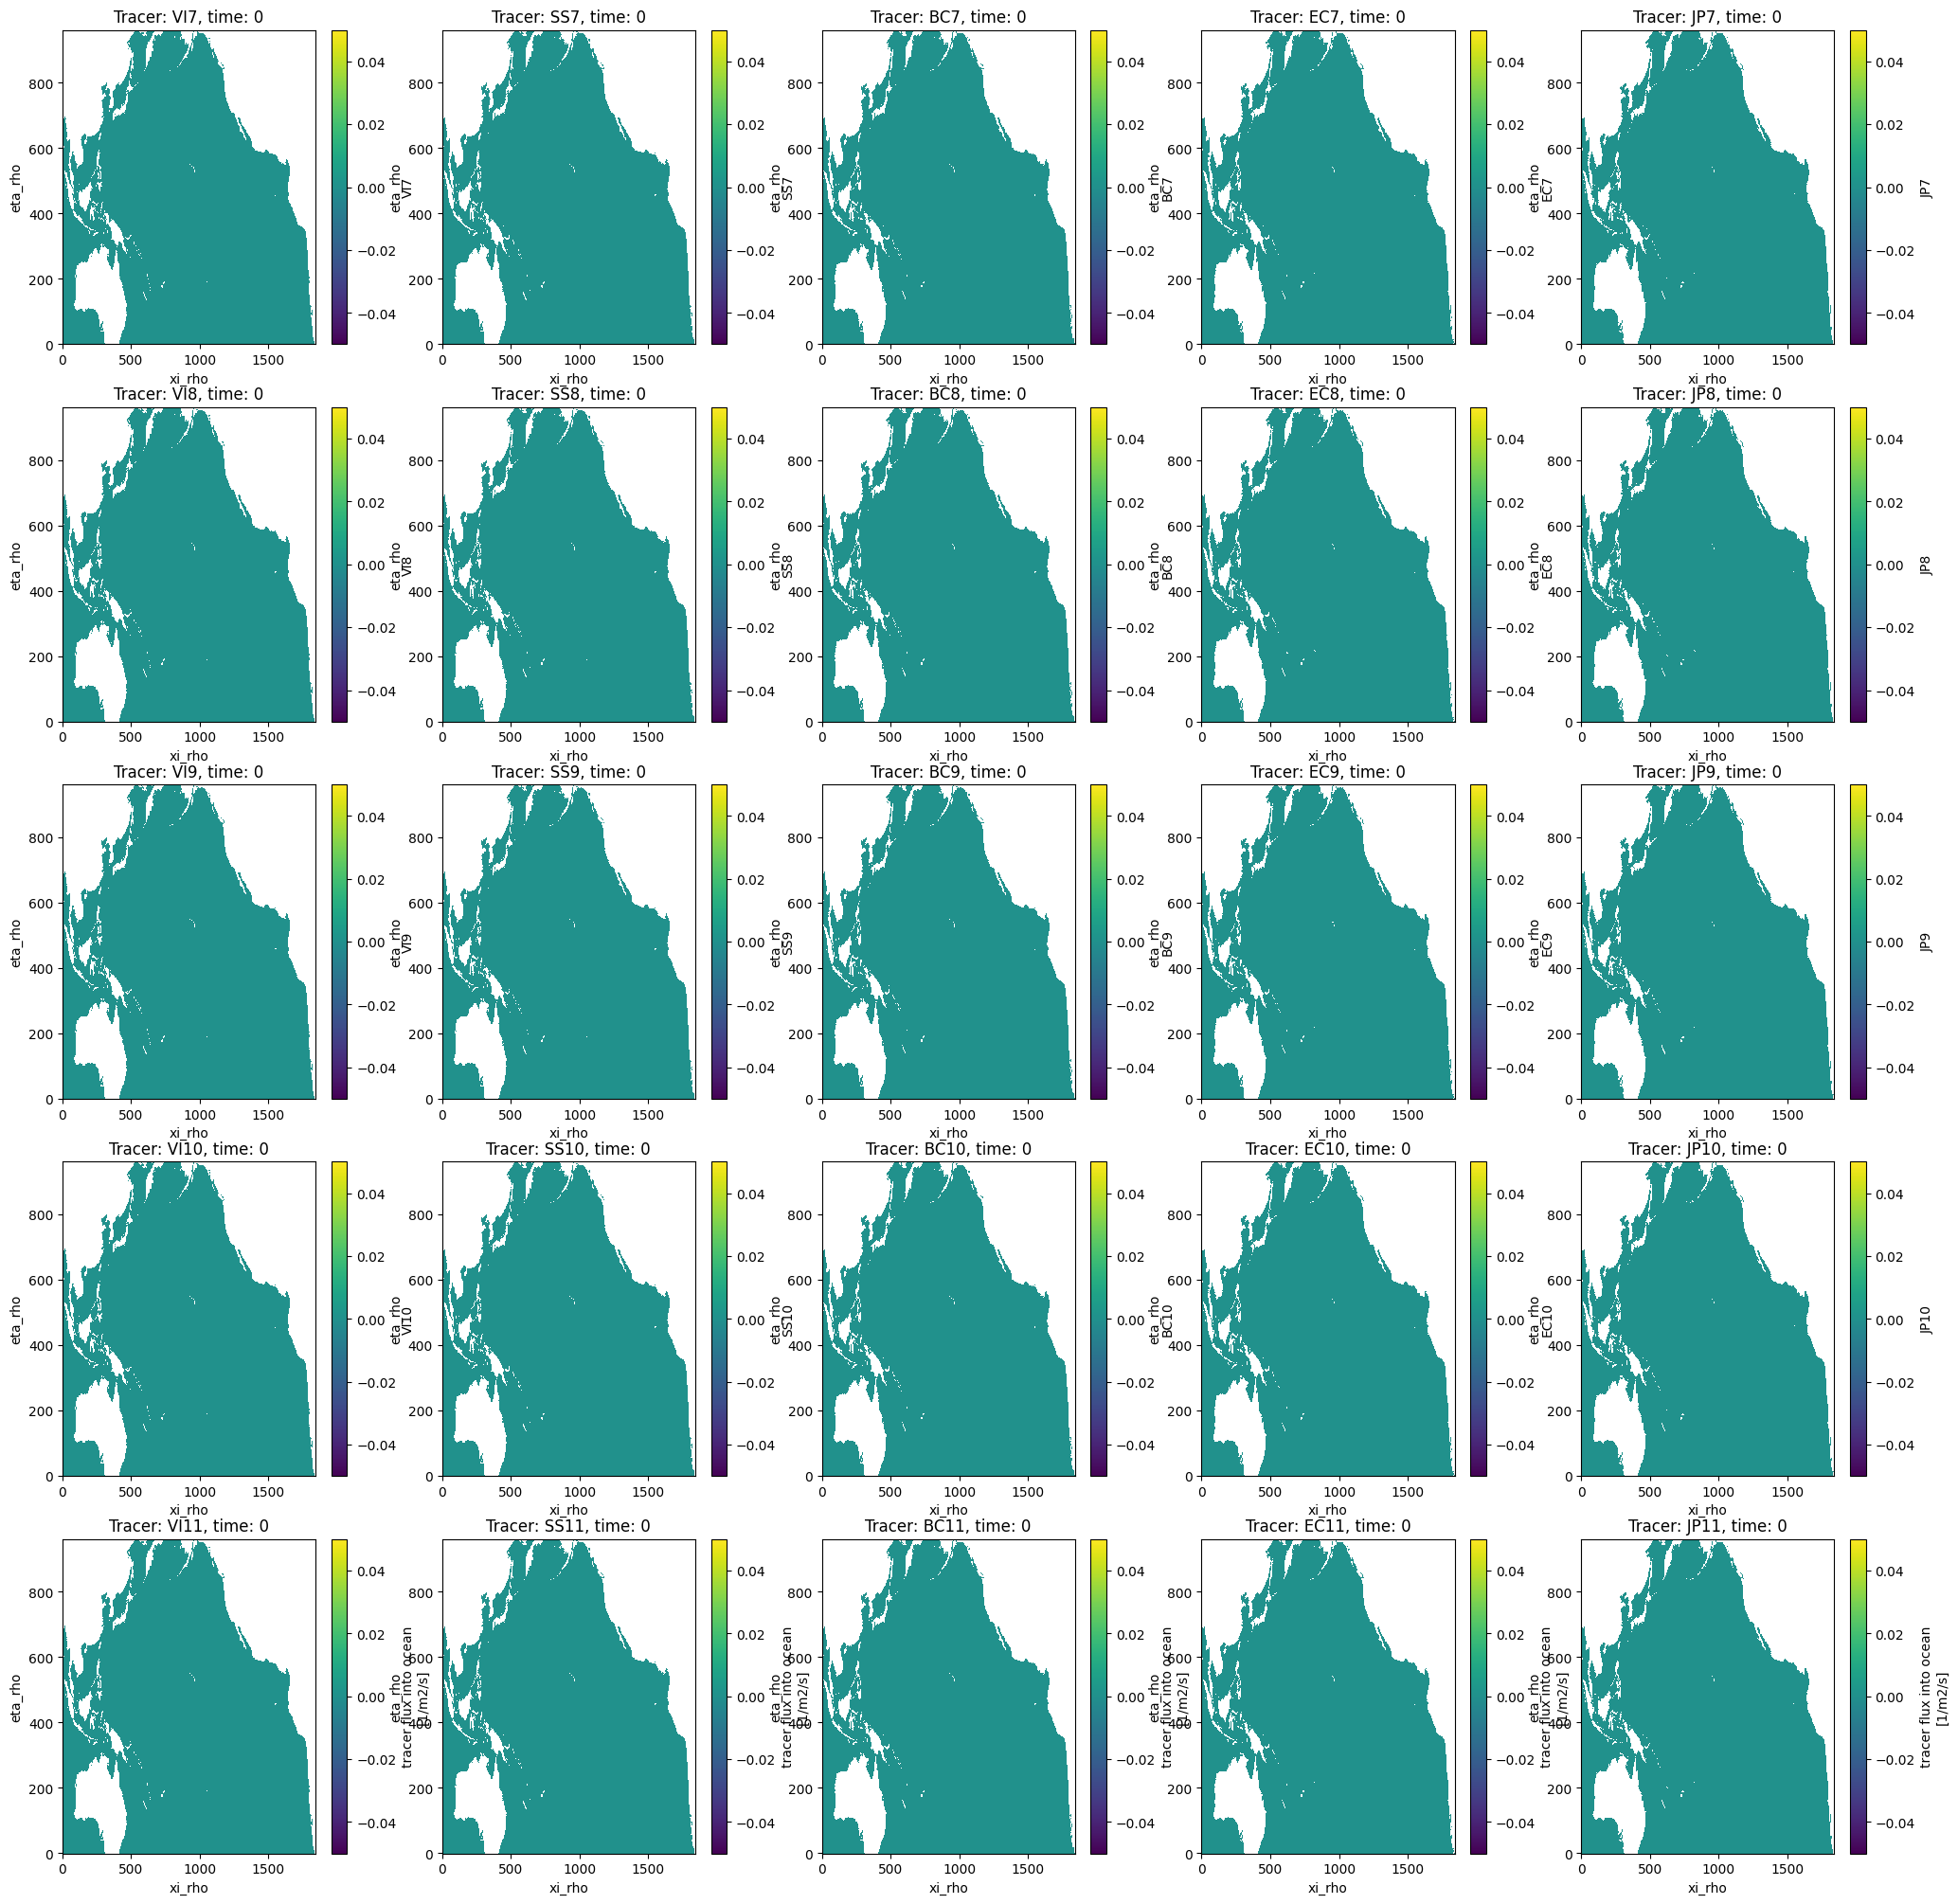

In [60]:
fig = plot_tracer(ds_1999, time=0)

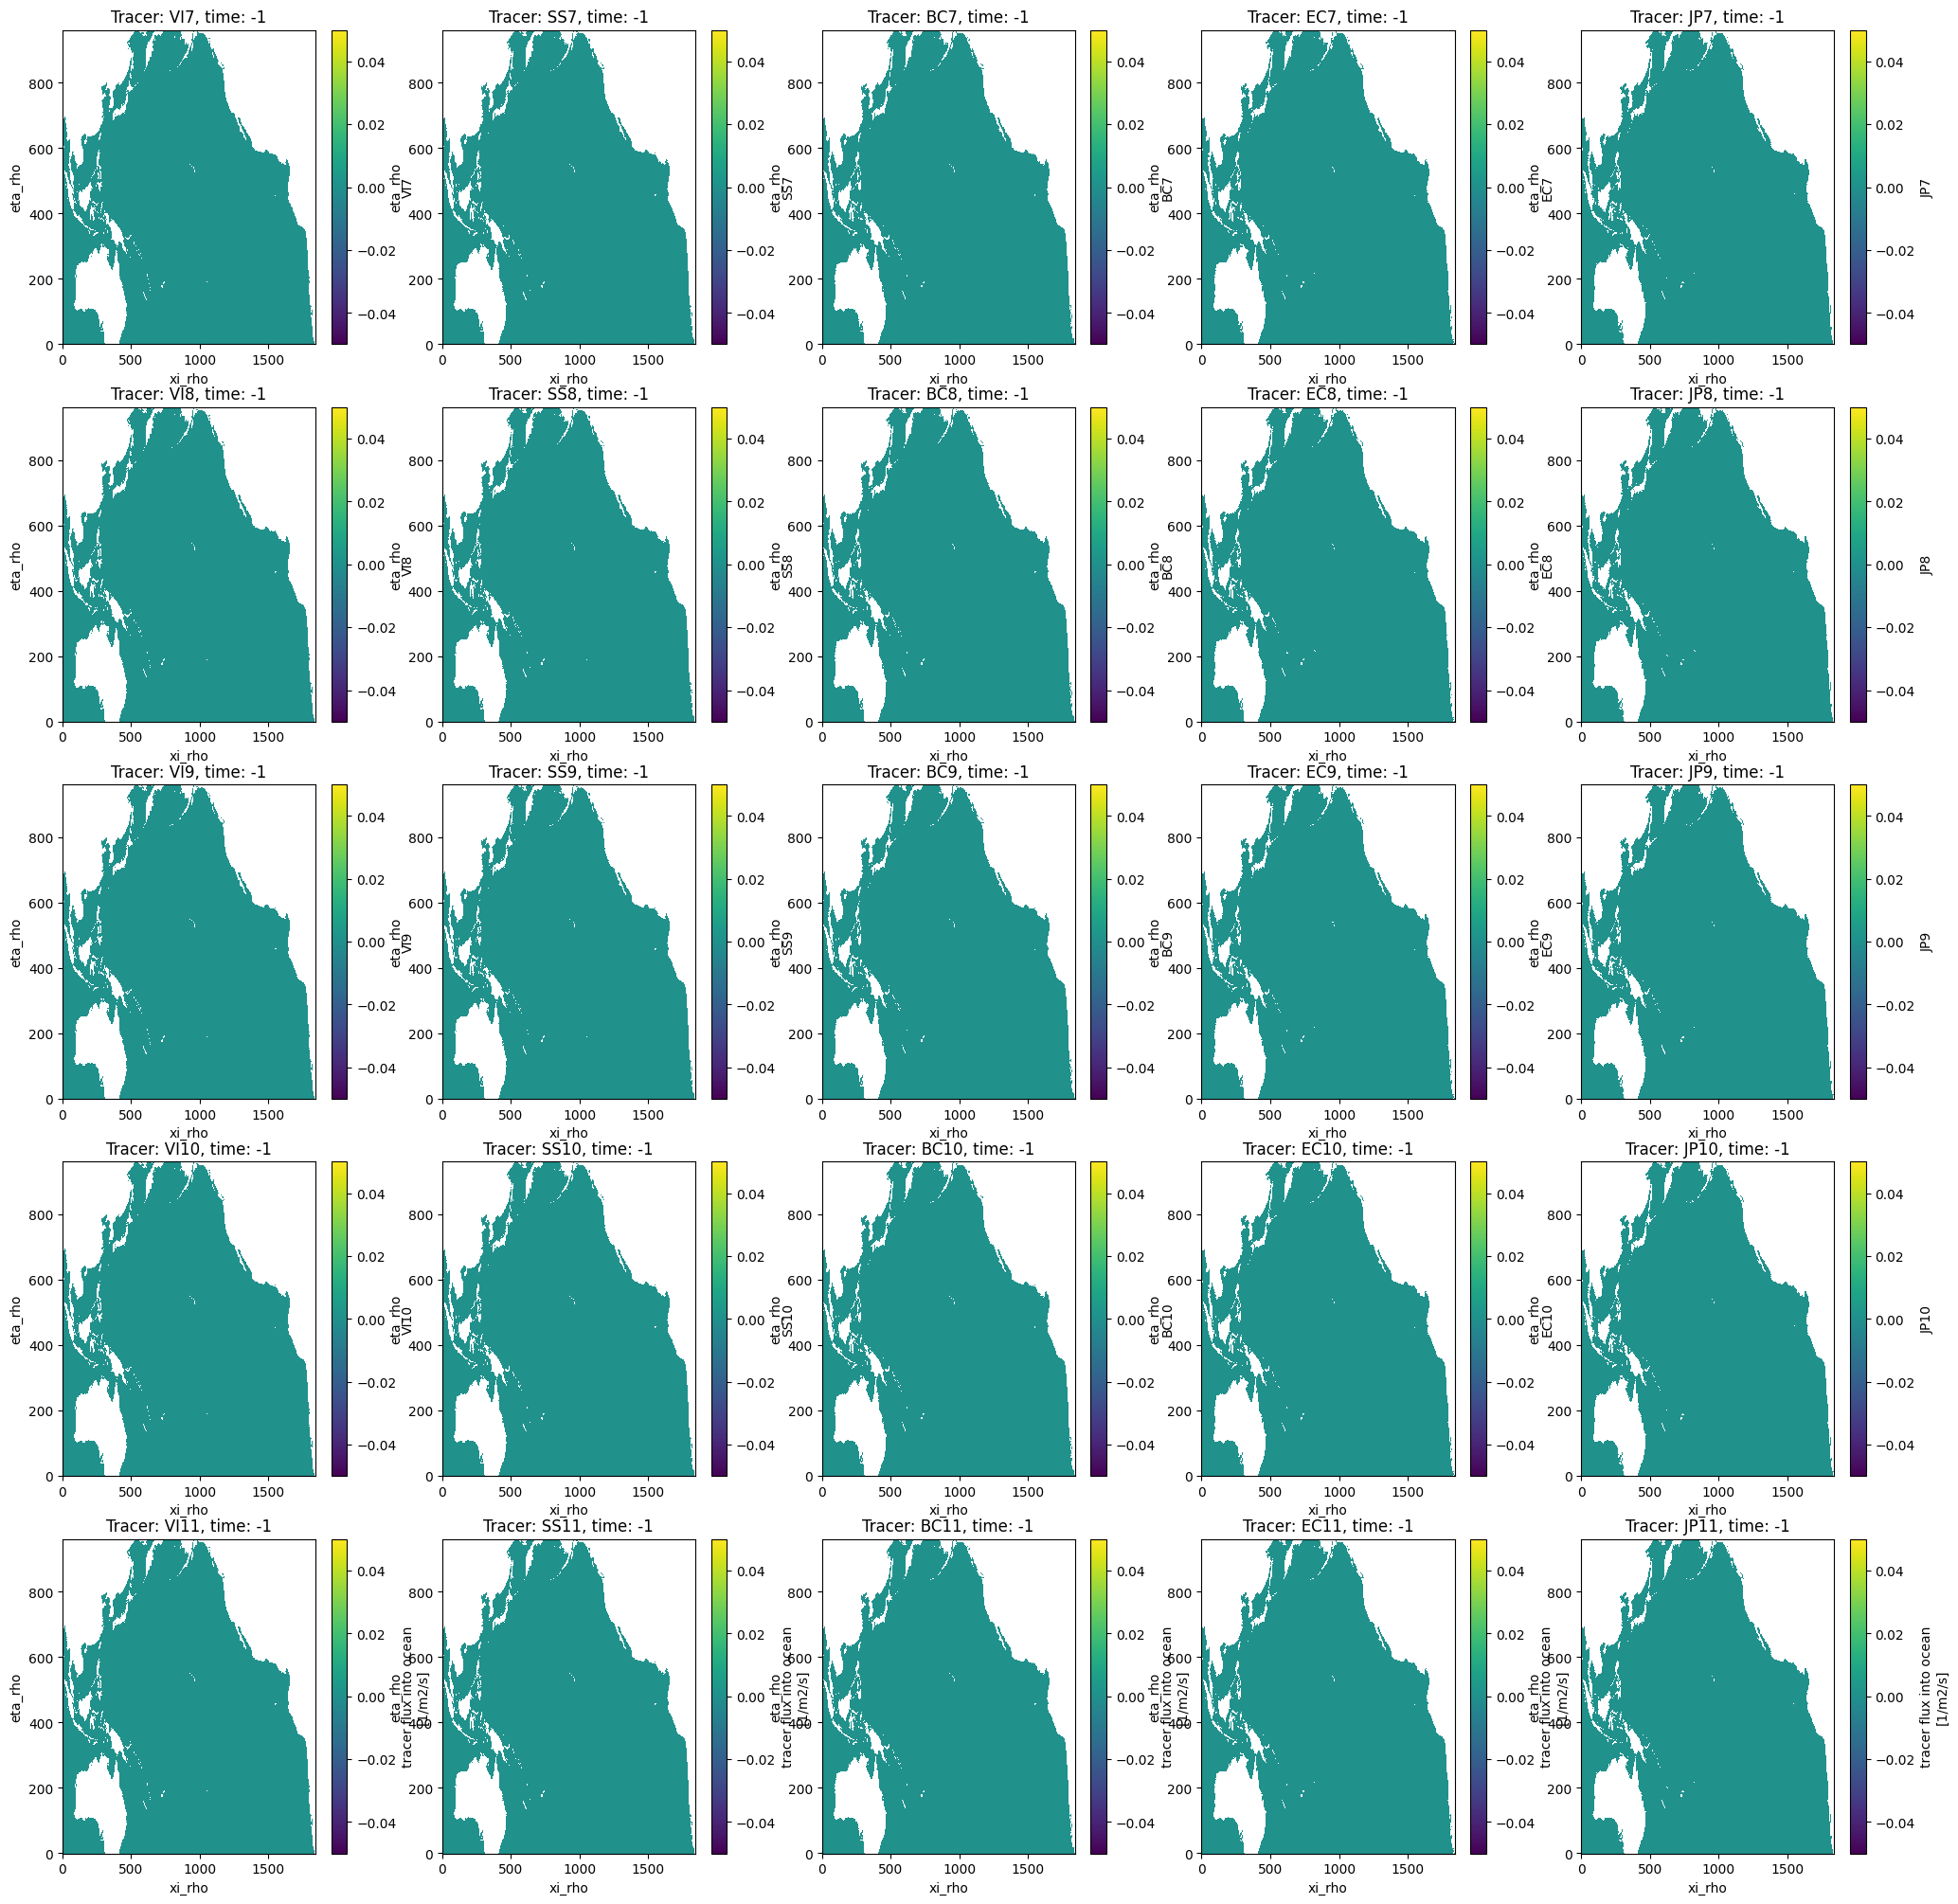

In [61]:
fig = plot_tracer(ds_1999, time=-1)

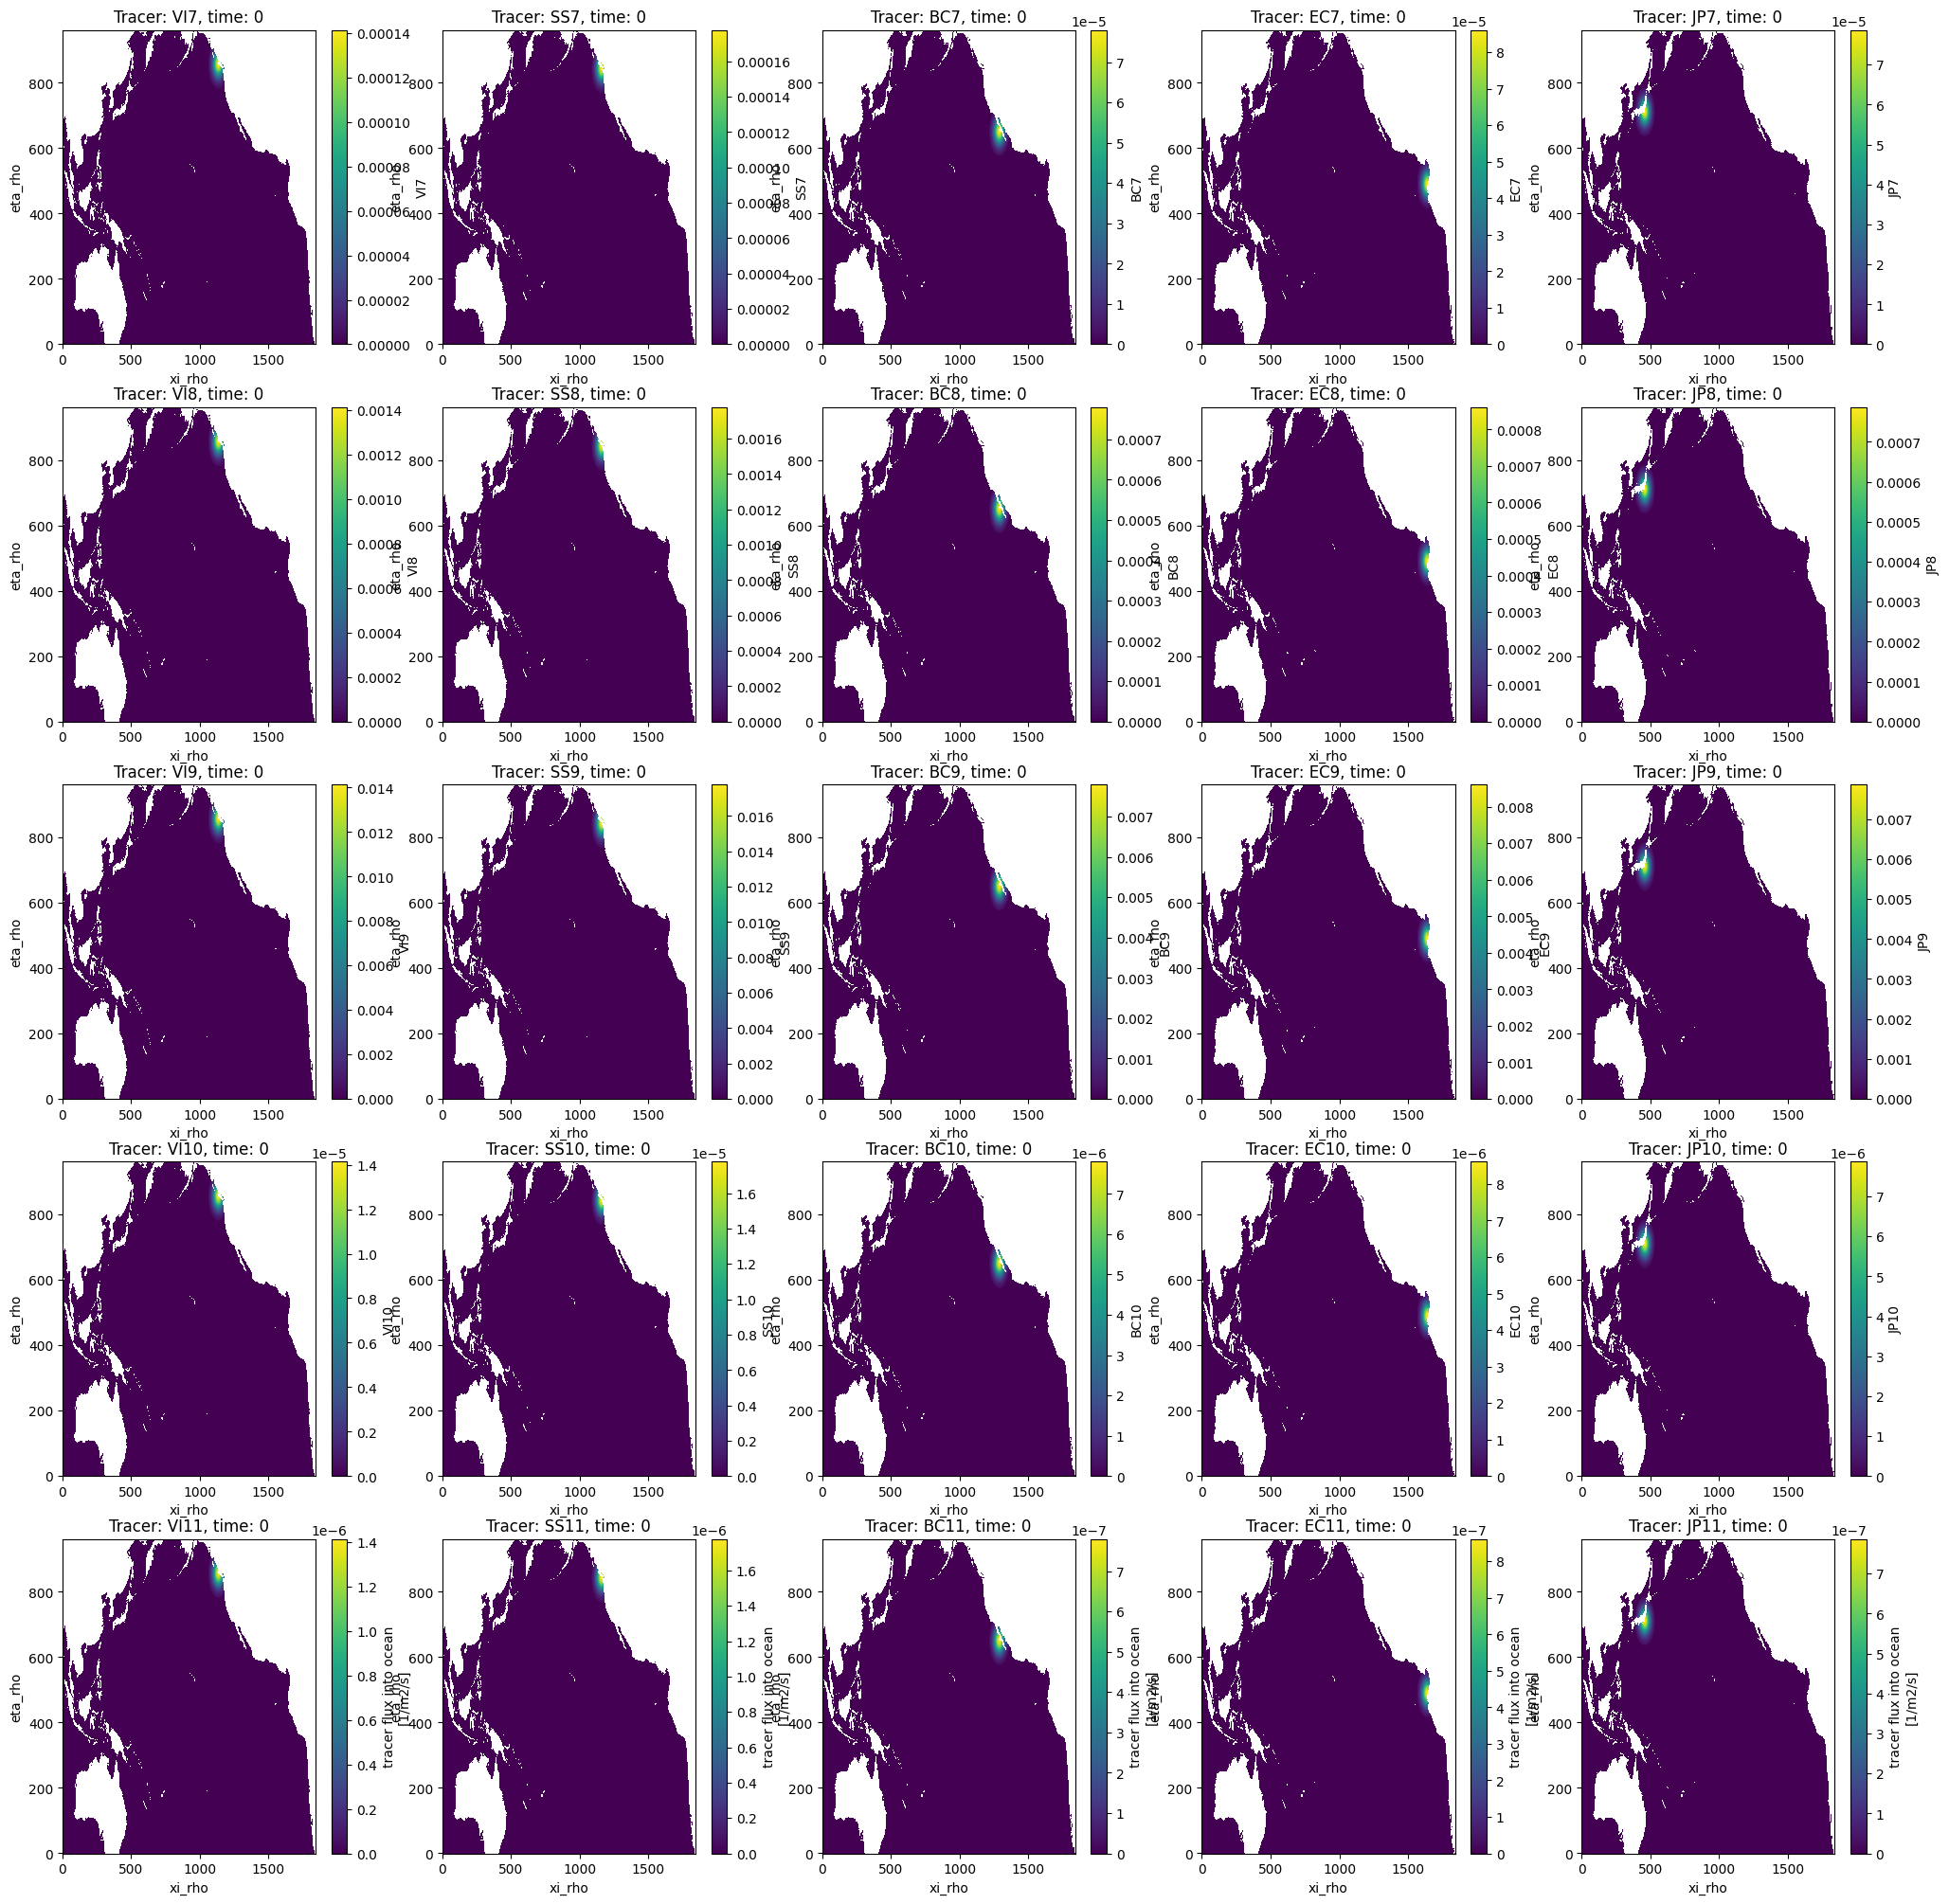

In [62]:
fig = plot_tracer(ds_2000, time=0)

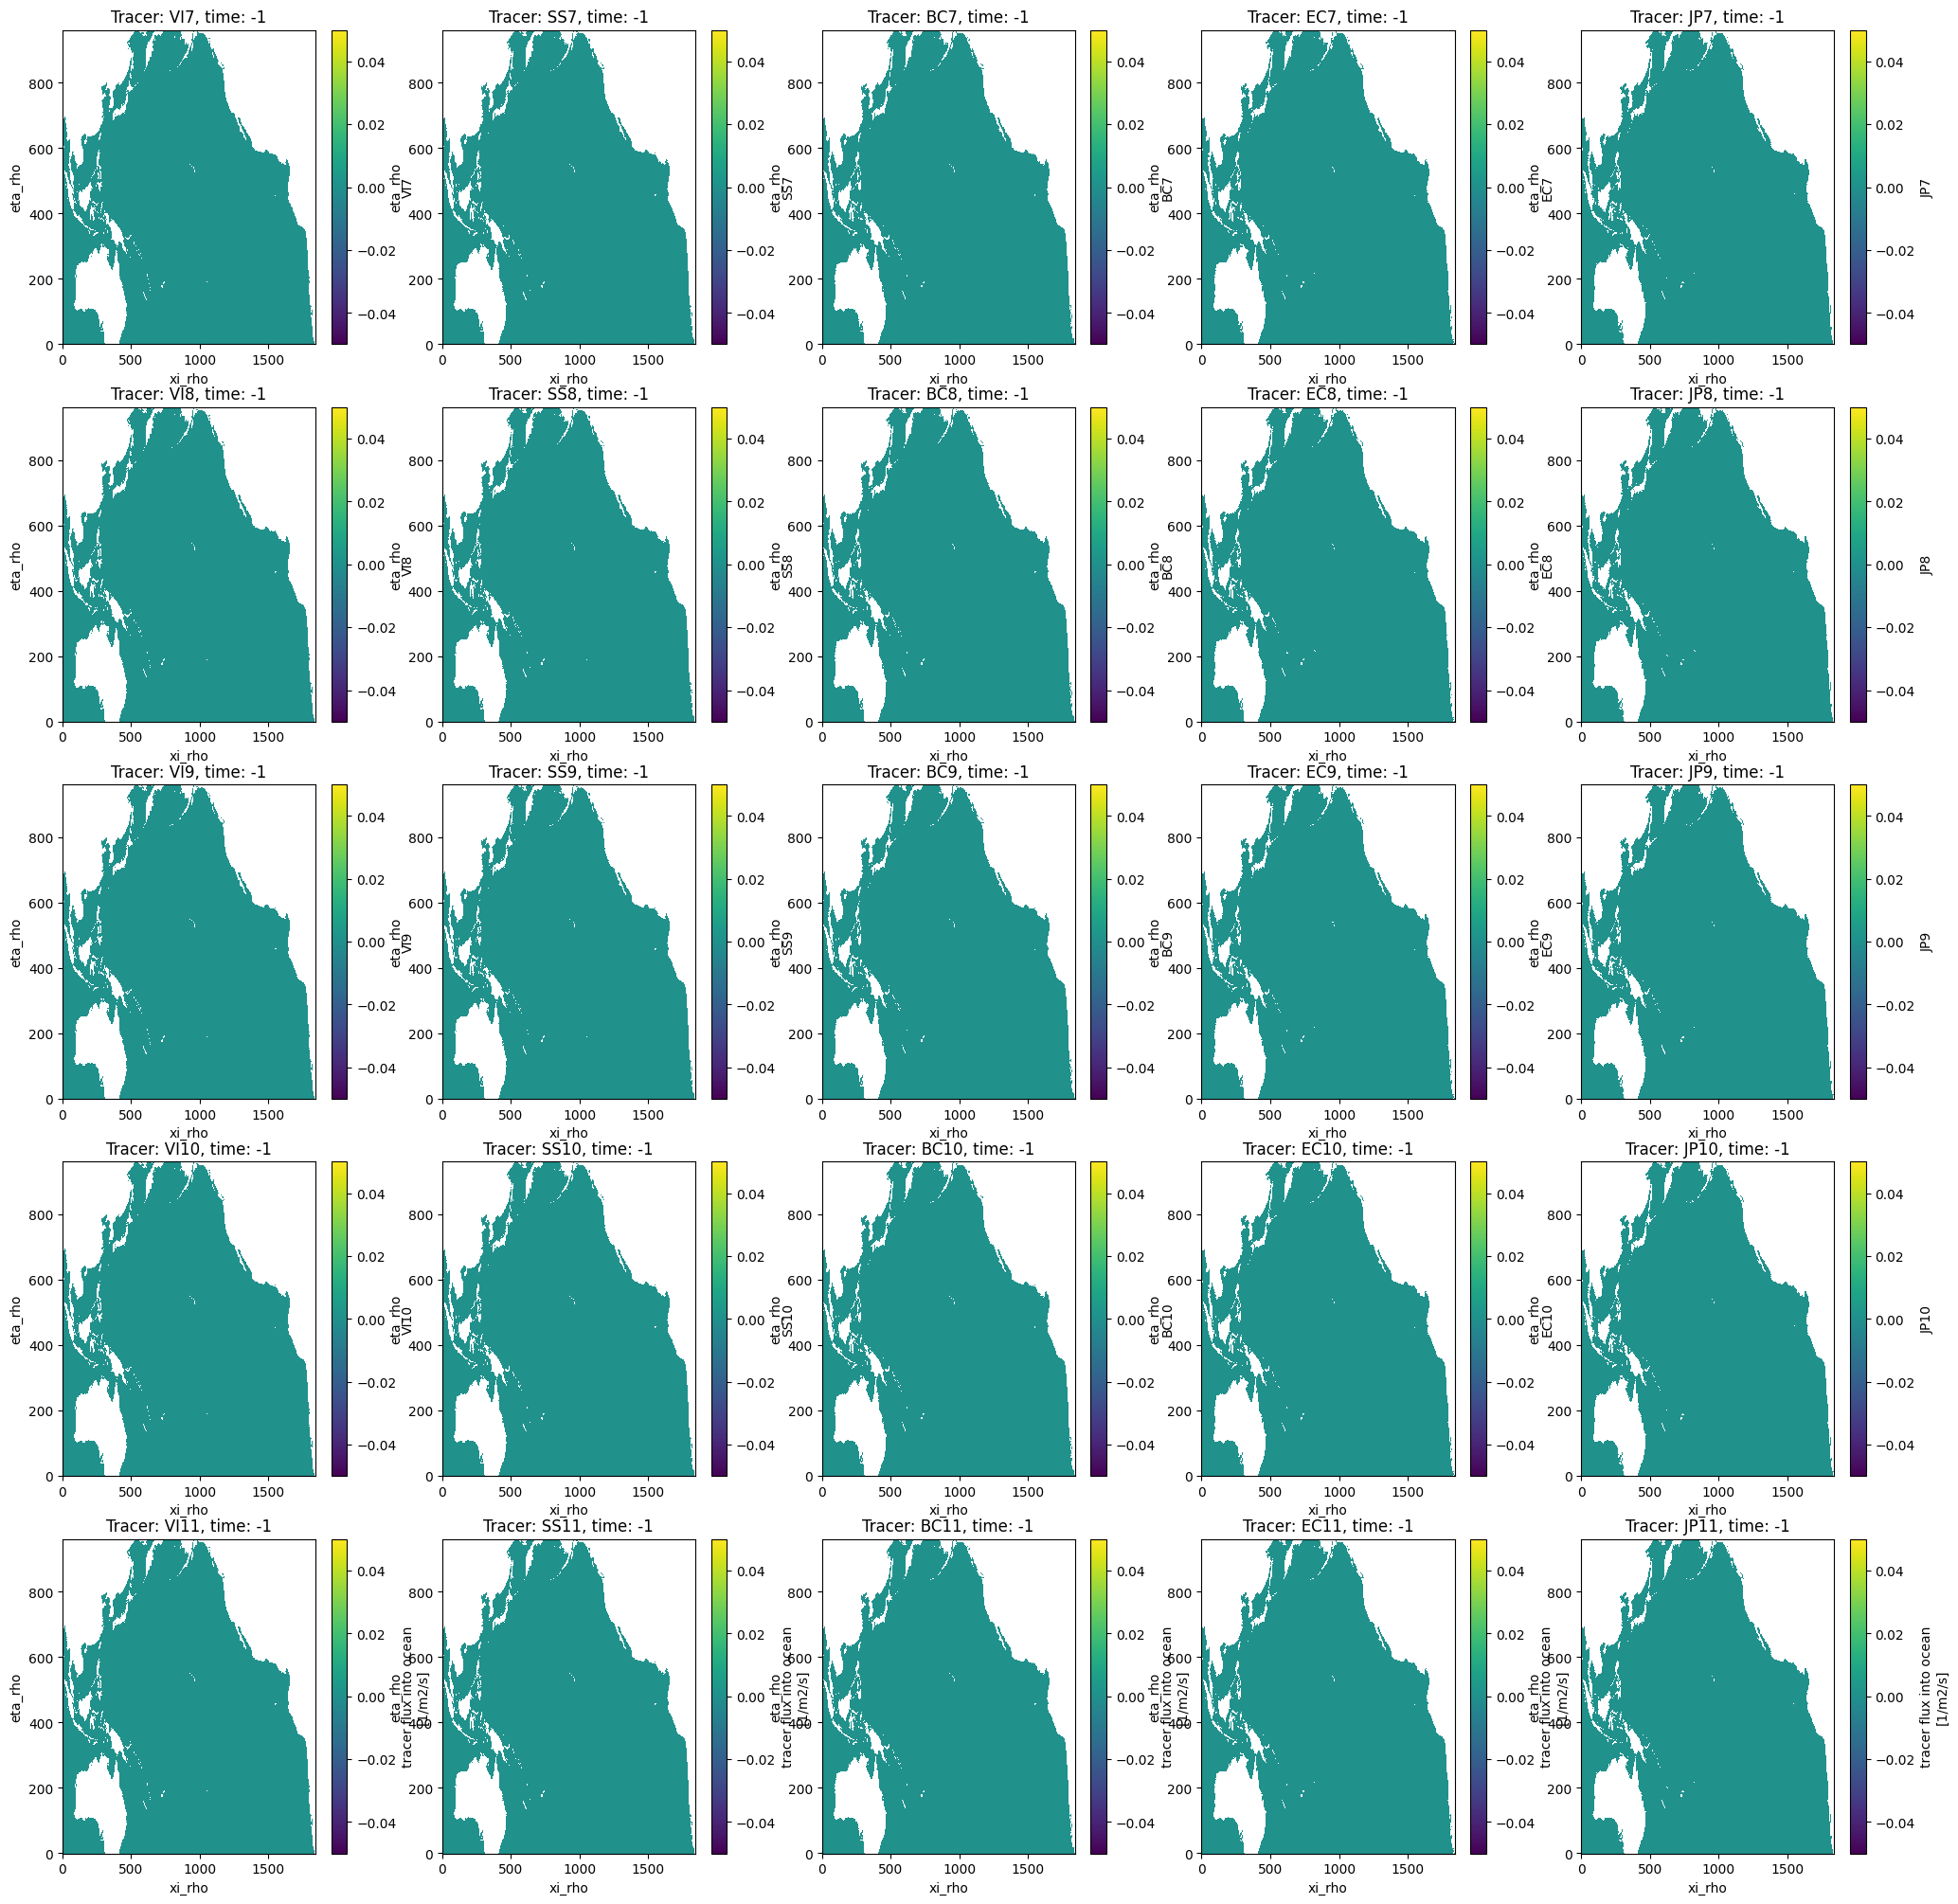

In [63]:
fig = plot_tracer(ds_2000, time=-1)

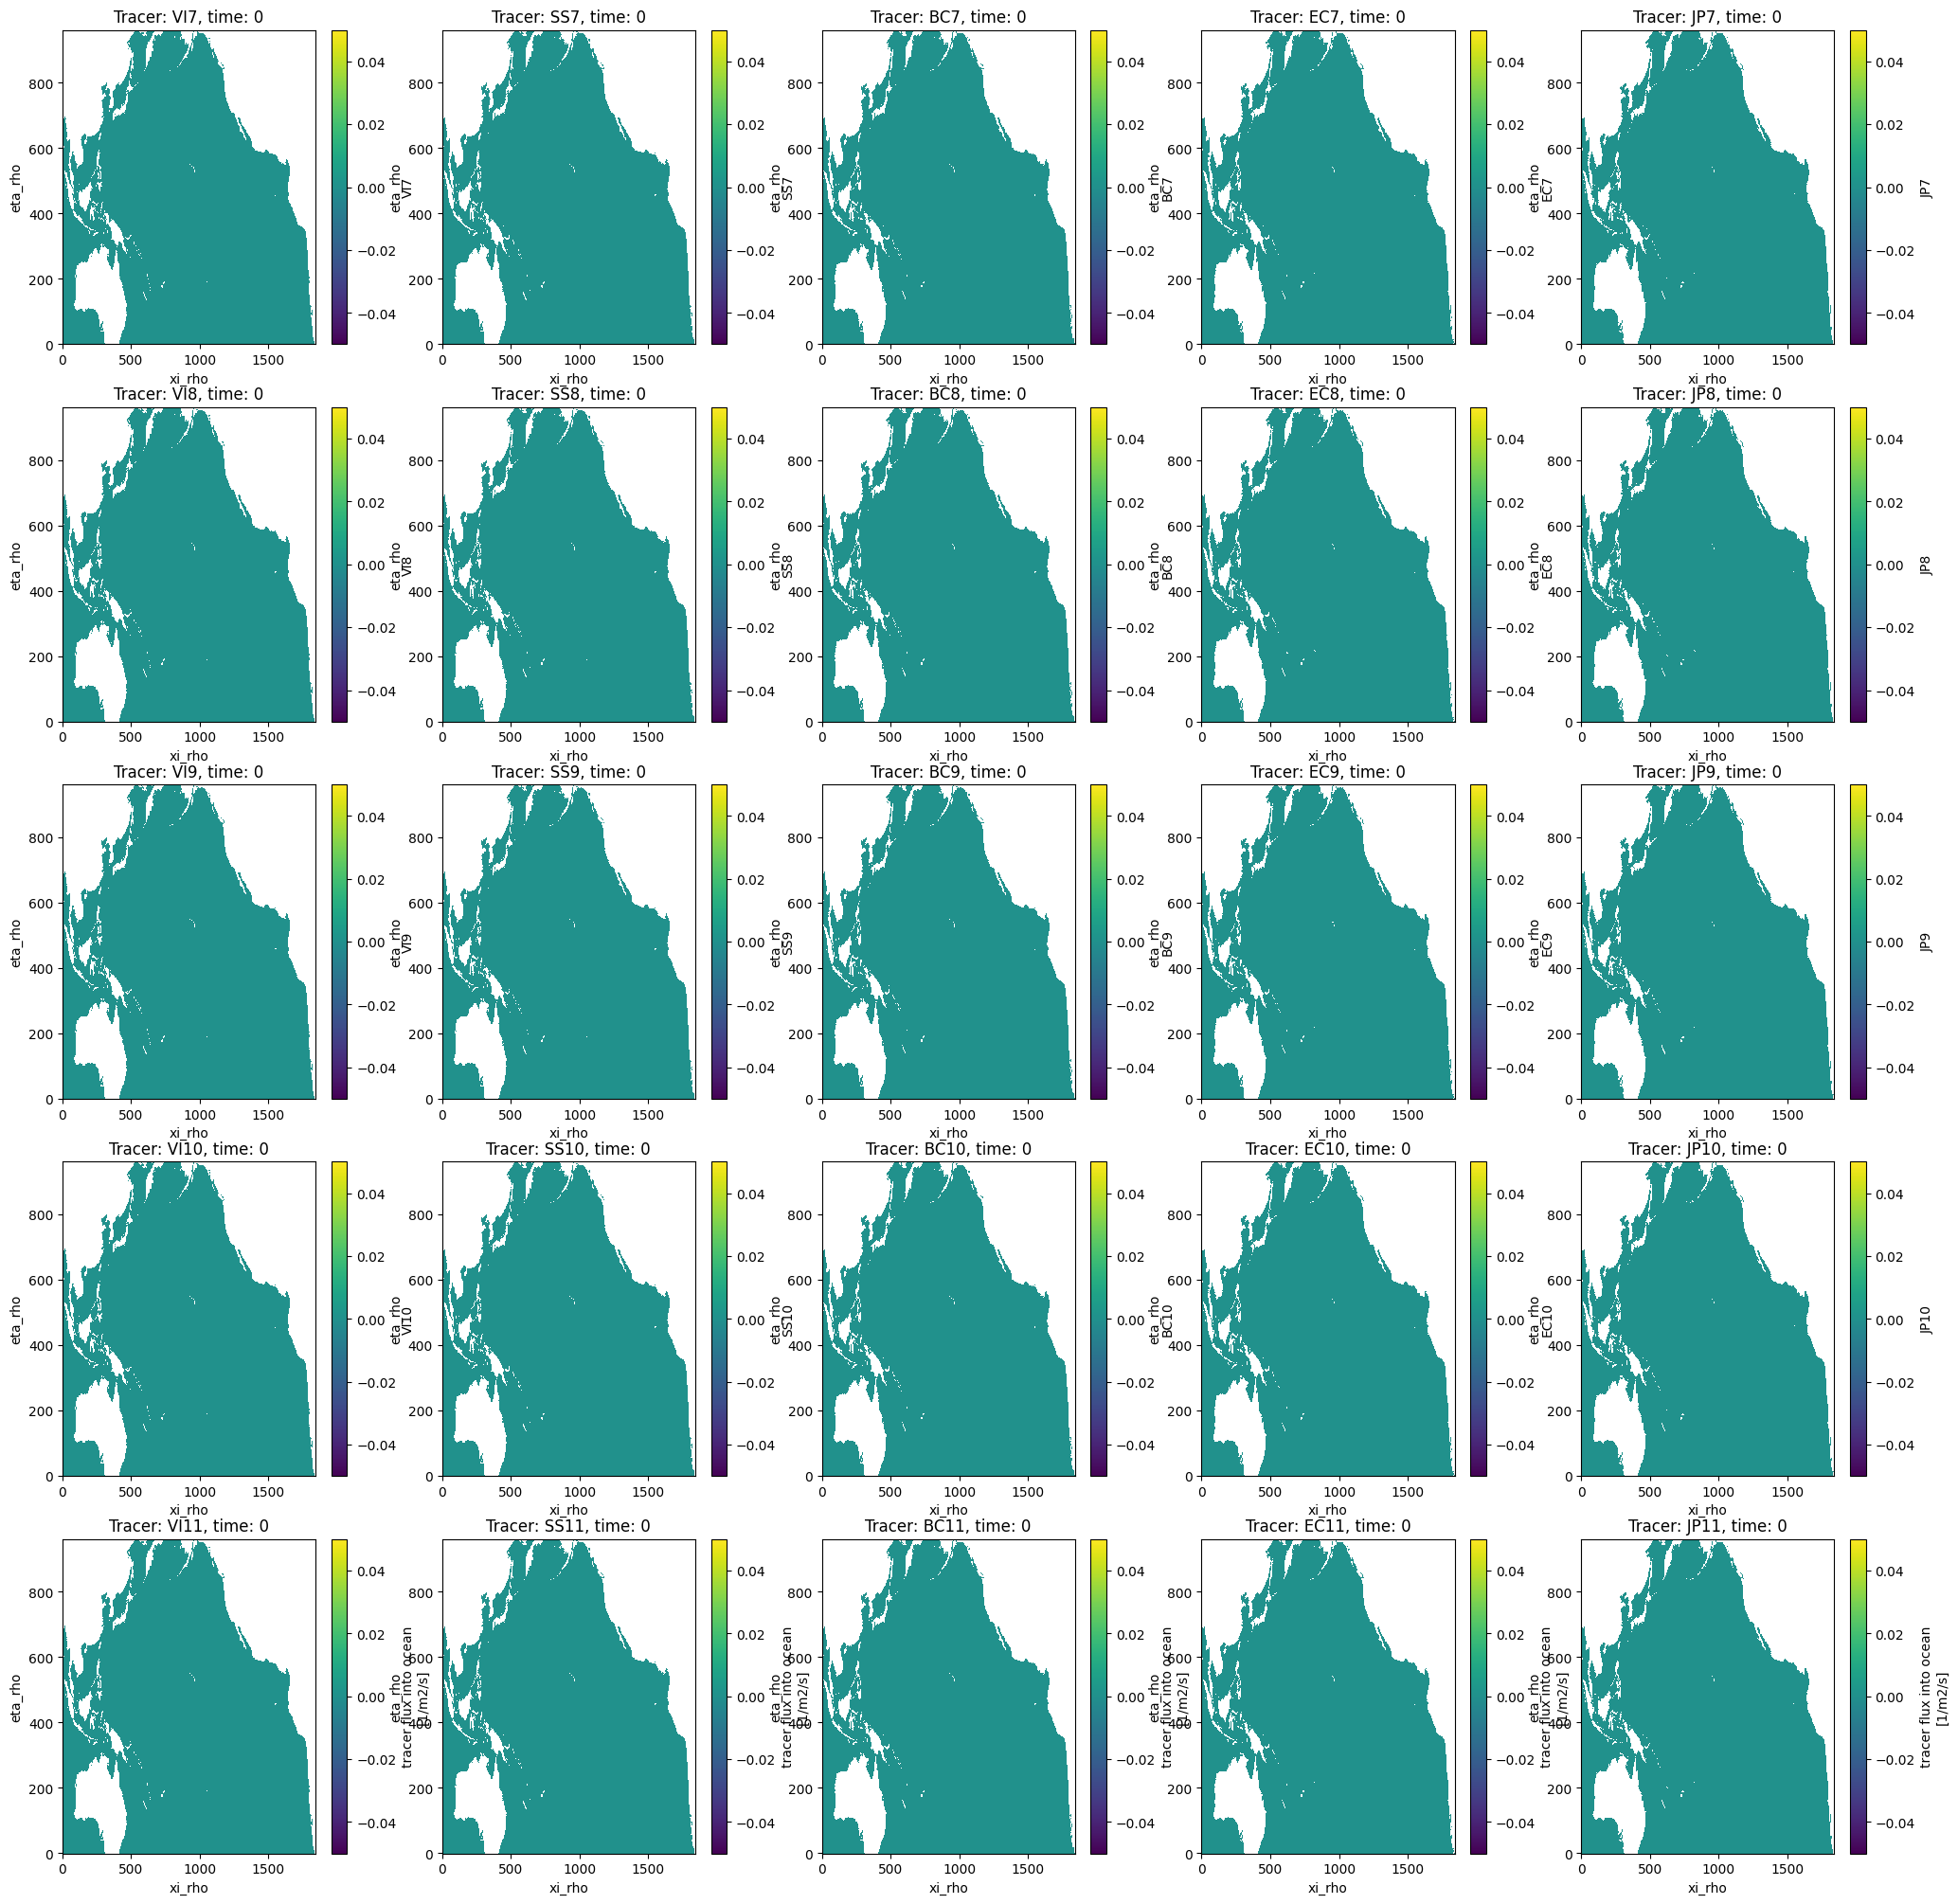

In [64]:
fig = plot_tracer(ds_2021, time=0)

In [66]:
import matplotlib.pyplot as plt

In [67]:
coords = {
    "VI": {"xi_rho": slice(1000, 1200), "eta_rho": slice(800, 900)},
    "SS": {"xi_rho": slice(1000, 1200), "eta_rho": slice(800, 900)},
    "BC": {"xi_rho": slice(1230, 1330), "eta_rho": slice(600, 700)},
    "EC": {"xi_rho": slice(1600, 1700), "eta_rho": slice(450, 550)},
    "JP": {"xi_rho": slice(420, 520), "eta_rho": slice(650, 750)},
}

def plot_separate_releases(tracer_name, convert=False):
    fig, axs = plt.subplots(1, 5, figsize=(25, 3.5))
    for i, ampl in enumerate(amplitudes.keys()):
        ax = axs.flatten()[i]
        field = ds_2000[f"{tracer_name}{ampl}"].isel(time=0).where(ds_grid.mask_rho).isel(**coords[tracer_name])
        if convert:
            field = field/1000*3600*24*365.25
            unit = "mol/m2/yr"
        else:
            unit = "mmol/m2/s"
        field.plot(ax=ax, cbar_kwargs={"label": unit})
        ax.set_title(f"Tracer: {tracer_name}{ampl}")
    
    for ax in axs.flatten():
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticks([])
        ax.set_yticks([])    

    return fig

### Plot Vancouver Island

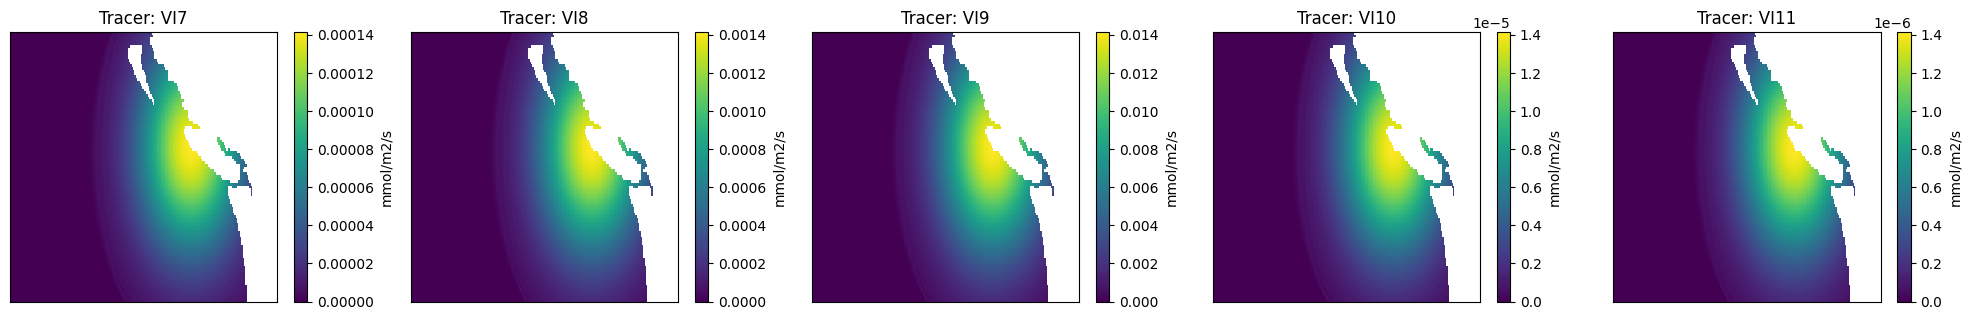

In [68]:
tracer_name = "VI"
fig = plot_separate_releases(tracer_name, convert=False)

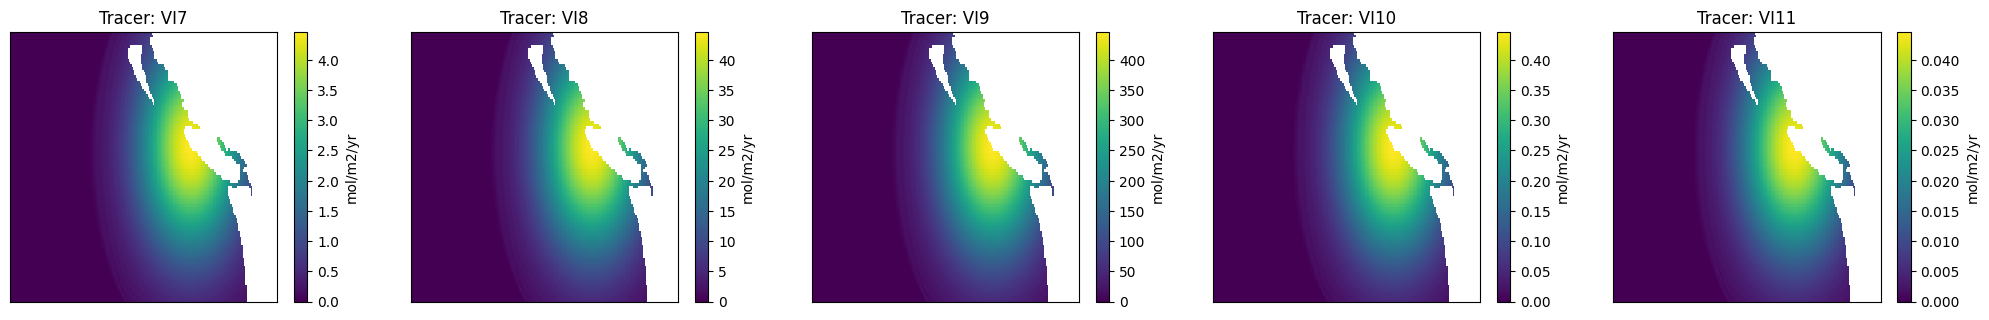

In [69]:
tracer_name = "VI"
fig = plot_separate_releases(tracer_name, convert=True)

### Plot Salish Sea

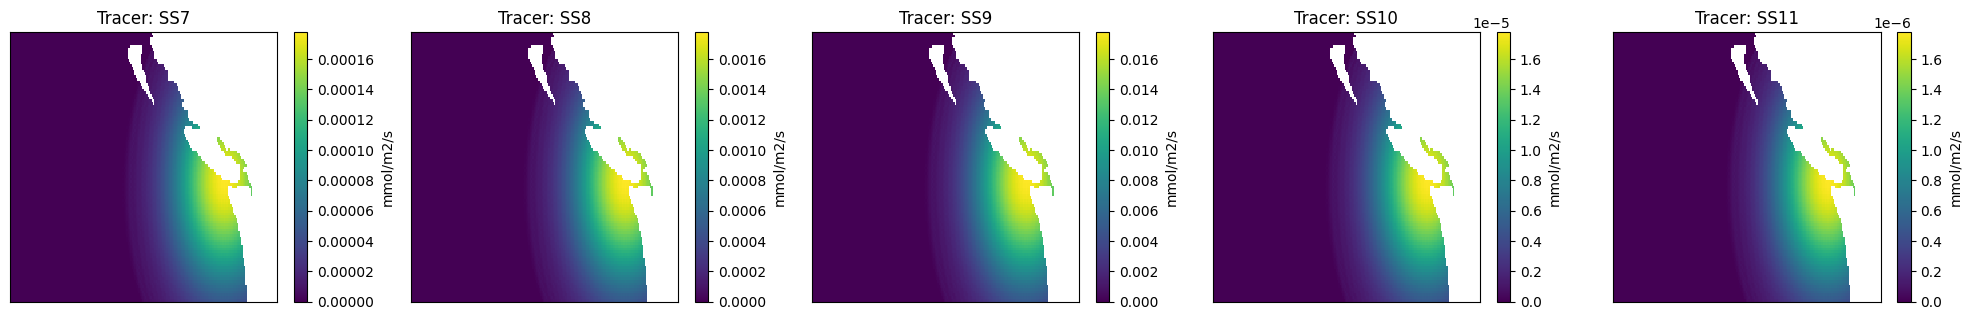

In [70]:
tracer_name = "SS"
fig = plot_separate_releases(tracer_name)

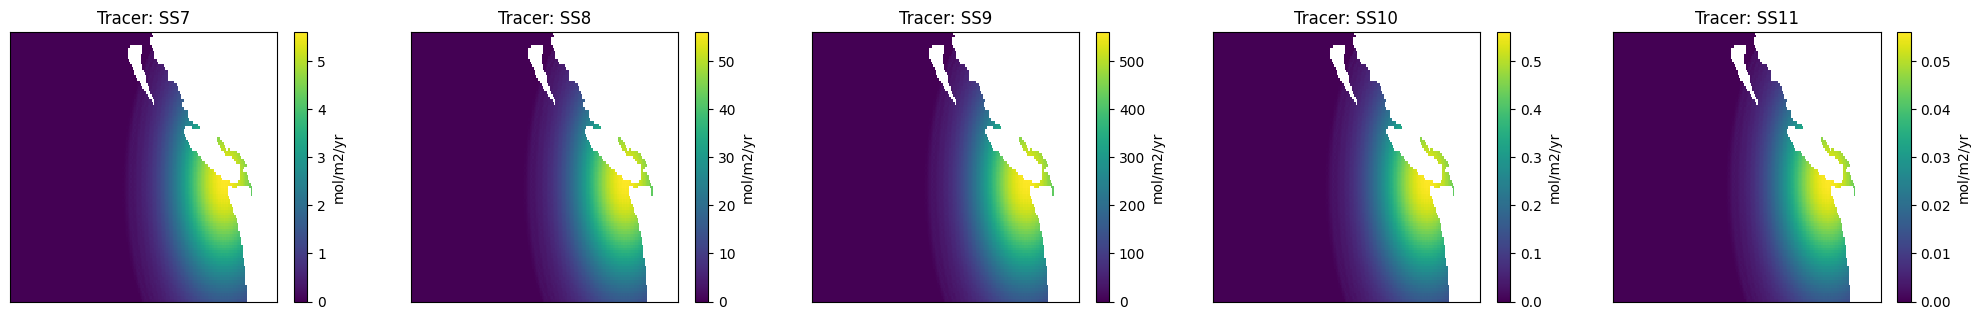

In [71]:
tracer_name = "SS"
fig = plot_separate_releases(tracer_name, convert=True)

### Plot Baja California

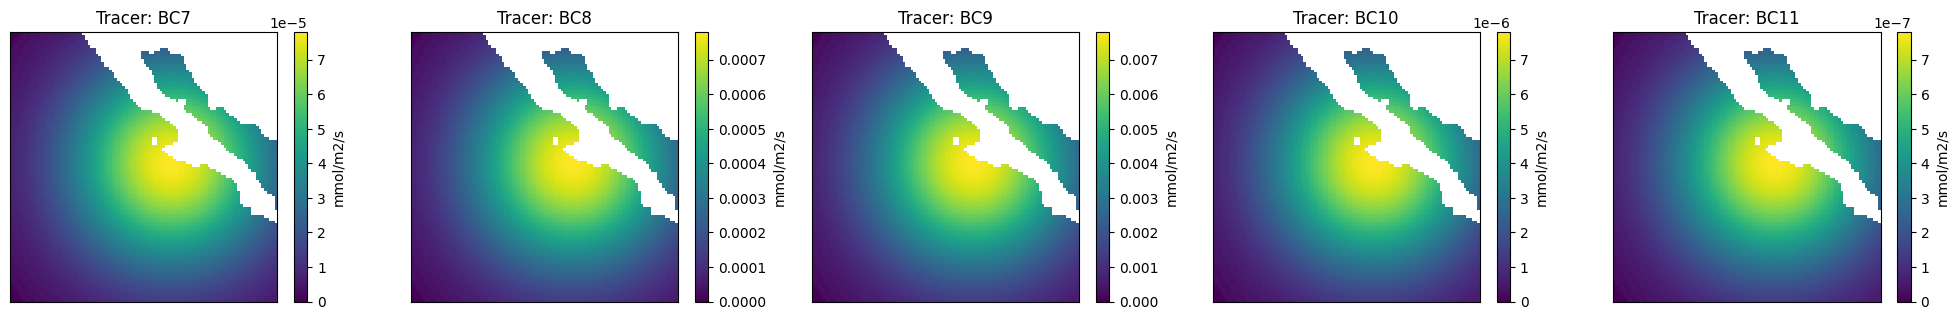

In [72]:
tracer_name = "BC"
fig = plot_separate_releases(tracer_name)

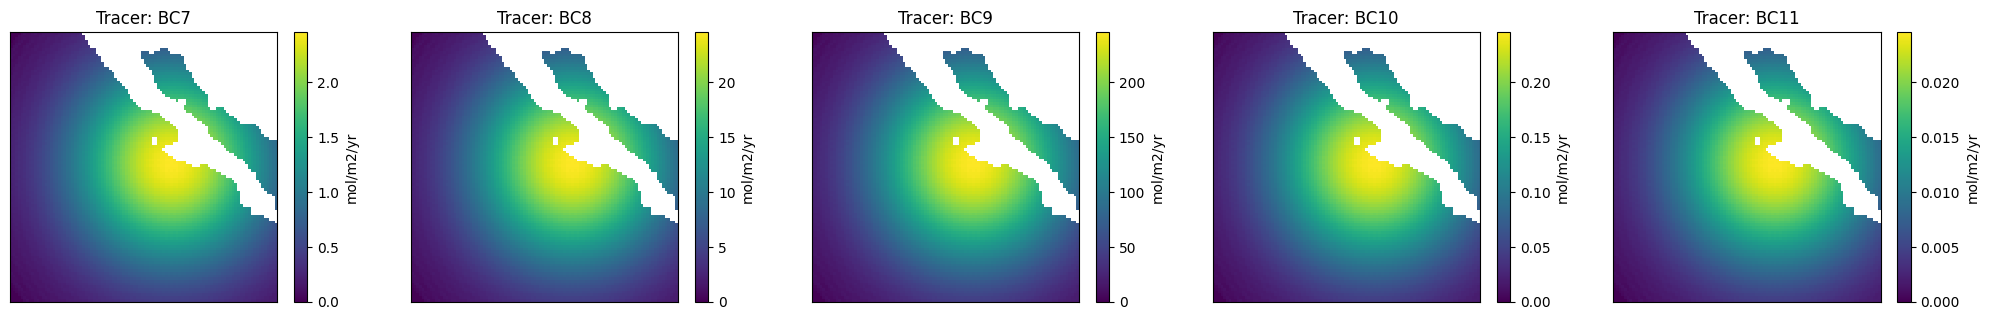

In [73]:
tracer_name = "BC"
fig = plot_separate_releases(tracer_name, convert=True)

### Plot Ecuador

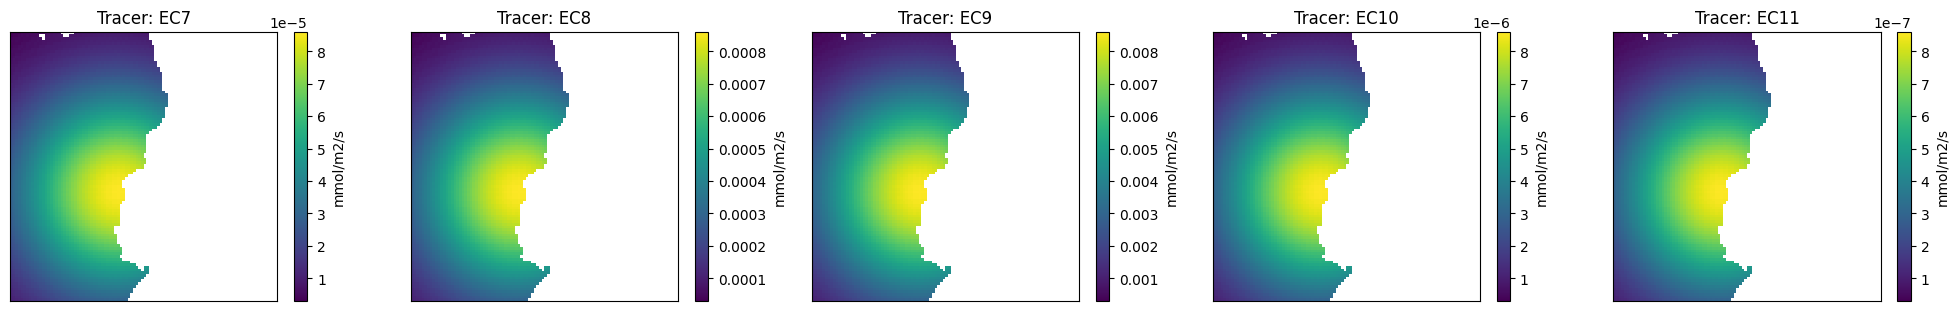

In [74]:
tracer_name = "EC"
fig = plot_separate_releases(tracer_name)

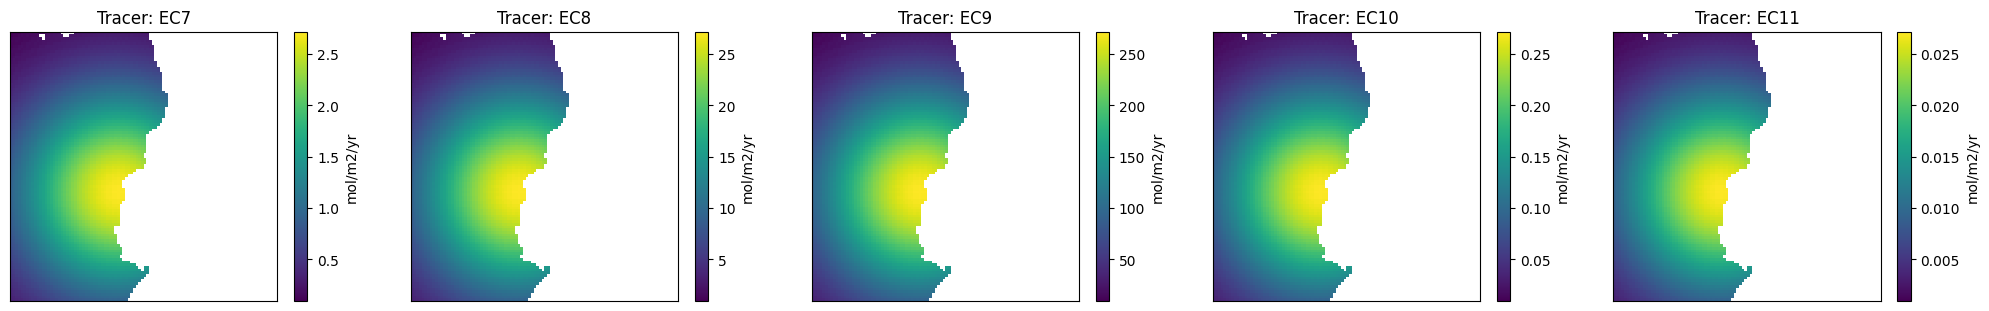

In [75]:
tracer_name = "EC"
fig = plot_separate_releases(tracer_name, convert=True)

### Plot Japan

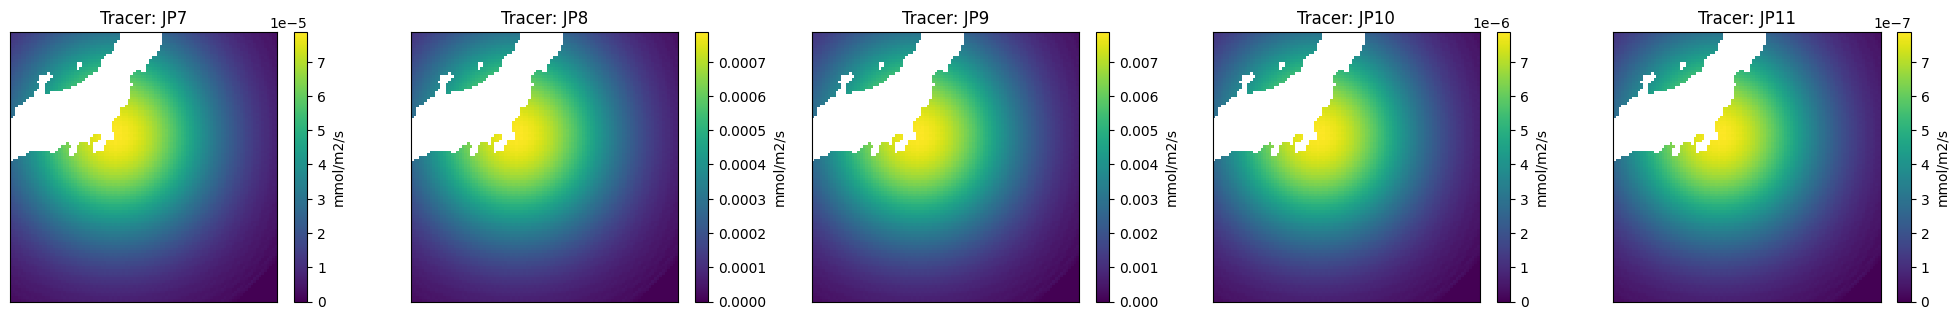

In [76]:
tracer_name = "JP"
fig = plot_separate_releases(tracer_name)

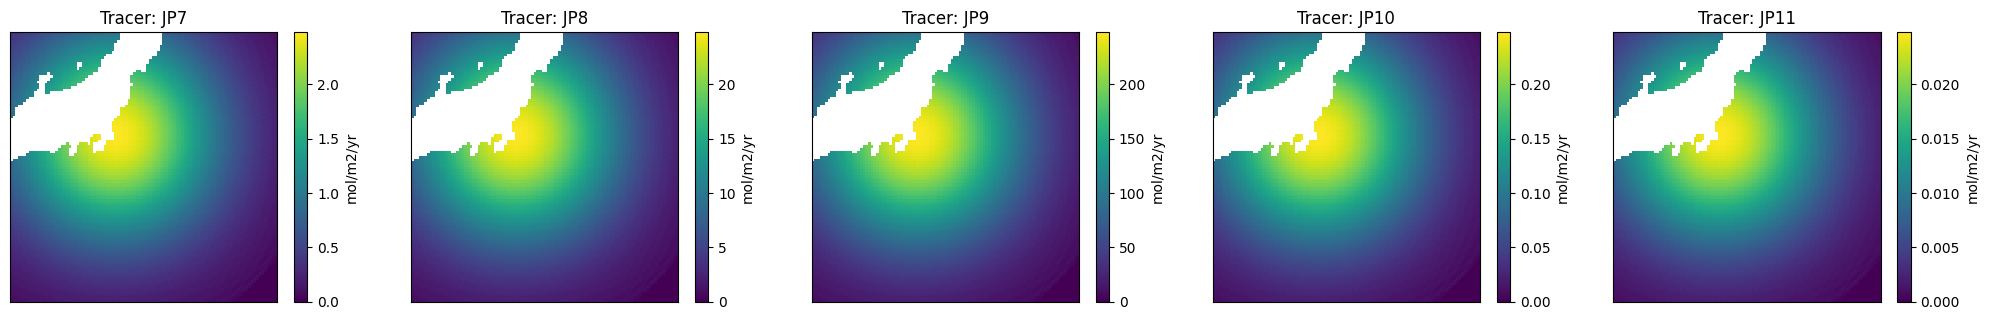

In [77]:
tracer_name = "JP"
fig = plot_separate_releases(tracer_name, convert=True)

### Compare to ref

In [78]:
import xarray as xr

In [79]:
ds = xr.open_dataset("/global/cfs/projectdirs/m4746/Projects/OAE-Efficiency-Map/data/alk-forcing/OAE-Efficiency-Map/alk-forcing-North_Atlantic_basin.000-1999-01.nc")

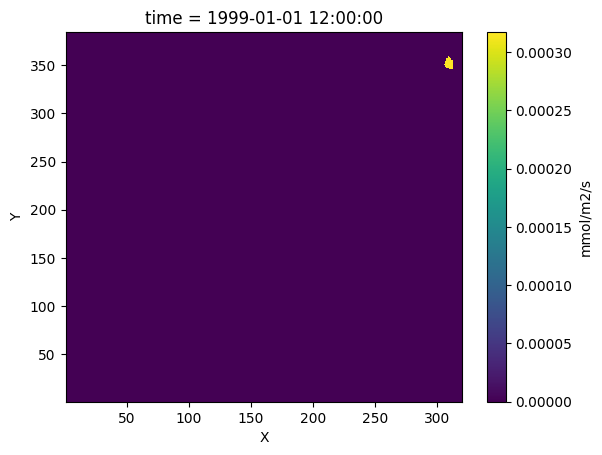

In [80]:
(1000 * ds.alk_forcing.isel(time=0)).plot(cbar_kwargs={"label": "mmol/m2/s"})

### Compute total tracer amount released

In [81]:
area = 1 / (ds_grid['pm'] * ds_grid['pn'])

In [82]:
for tracer_name, release in releases.items():
    for ampl, factor in amplitudes.items():
        integral = (ds_2000[f"{tracer_name}{ampl}"].isel(time=0) * area * 3600 * 24 * 31).sum(dim=["eta_rho", "xi_rho"]).values
        print(f"{tracer_name}{ampl}: {integral:.3e}")

VI7: 1.000e+14
VI8: 1.000e+15
VI9: 1.000e+16
VI10: 1.000e+13
VI11: 1.000e+12
SS7: 1.000e+14
SS8: 1.000e+15
SS9: 1.000e+16
SS10: 1.000e+13
SS11: 1.000e+12
BC7: 1.000e+14
BC8: 1.000e+15
BC9: 1.000e+16
BC10: 1.000e+13
BC11: 1.000e+12
EC7: 1.000e+14
EC8: 1.000e+15
EC9: 1.000e+16
EC10: 1.000e+13
EC11: 1.000e+12
JP7: 1.000e+14
JP8: 1.000e+15
JP9: 1.000e+16
JP10: 1.000e+13
JP11: 1.000e+12


* 7: 10^14 mmol = 10^11 mol = 100 Gmol
* 8: 10^15 mmol = 10^12 mol = 1 Tmol
* 9: 10^16 mmol = 10^13 mol = 10 Tmol
* 10: 10^13 mmol = 10^10 mol = 10 Gmol

### Save

In [83]:
ds_1999.to_netcdf("../../INPUT/roms_tracer_surf_flux_1999.nc")
ds_2000.to_netcdf("../../INPUT/roms_tracer_surf_flux_2000.nc")
ds_2021.to_netcdf("../../INPUT/roms_tracer_surf_flux_2021.nc")

### Back-of-envelope comparison to Zhou et al. (2025)

Zhou et al.:
* use ALK flux of 10 mol m-2 yr-1 over one month.
* polygons have area of approx. 0.2 * 10^6 * 1000^2 m2 (EEZ) and 0.7 * 10^6 * 1000^2 m2 (open ocean)
* median values: 2.4 * 10^5 * 1000^2 m2 (EEZ), 7.2 * 10^5 * 1000^2 m2 (EEZ)
* Total alkalinity added (over 1 month): **1.67 * 10^11 mol** (EEZ), **4 * 10^11 - 9 * 10^11 mol** (open ocean)
* Median values:

Tyka, 2025:
* 5 Gmol = 5 × 10¹² mmol
* 500 Gmol = 5 × 10¹⁴ mmol
* 50 Tmol = 5 × 10¹⁶ mmol

In [6]:
alk_flux = 10 / 365.25 / 24 / 3600
alk_flux

3.168808781402895e-07

10 mol m-2 yr-1 are approx. 3 * 10^-7 mol/m2/s.

In [7]:
area_pol = 0.24 * 10**6 * 1000**2
area_pol

240000000000.0

In [9]:
area_pol = 0.72 * 10**6 * 1000**2
area_pol

720000000000.0

In [8]:
total_alk = alk_flux * area_pol * 3600 * 24 * 30.5
total_alk

200410677618.0698

That's  2 e+11 mol = 200 Gmol

In [10]:
total_alk = alk_flux * area_pol * 3600 * 24 * 30.5
total_alk

601232032854.2094

That's  6 e+11 mol = 600 Gmol